# Principal component analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Exercise 1: Principal components
Below we provide a two-dimensional zero-mean dataset $\mathbf{X}\in\mathbb{R}^{N \times D}$ of $N$ examples and $D=2$ features.
1. Plot the data as a scatter plot;
1. Compute the covariance matrix of this data;
1. Compute the eigenvalue decomposition of the covariance matrix to find the PCs;
1. Plot the PCs on this scatter plot. **Hint:** The directions of the PCs are given by the eigenvectors of the sample covariance matrix. Scale the length of the PCs using the square root of the eigenvalues of the sample covariance matrix.
1. Why do the PCs point in these directions?

In [42]:
def make_pca_1(N, seed=42):
    rng = np.random.default_rng(seed)
    cov = [[0.97, 0.64], [0.64, 0.96]]
    return rng.multivariate_normal([0.0, 0.0], cov, size=N)

X = make_pca_1(N=200)

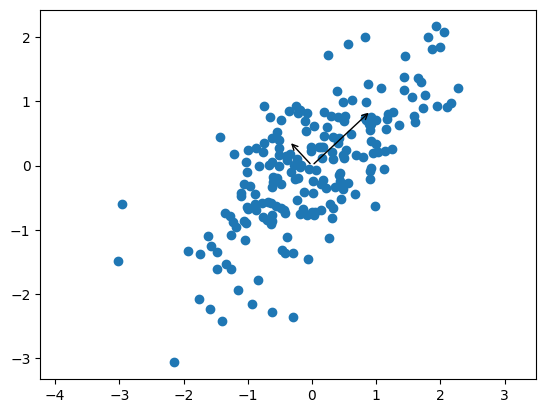

In [43]:
def plot(X):
    cov_mat = np.cov(X.T)

    plt.scatter(*X.T)
    plt.axis("equal")  # So scale of eigenvectors is more clear.
    
    eigenvals, eigenvecs = np.linalg.eig(cov_mat)
    for val, vec in zip(eigenvals, eigenvecs.T):
        plt.annotate("", xytext=(0, 0), xy=vec * np.sqrt(val),  # NOTE: Why vec * sqrt(val) instead of l2_norm(vec) * val?
                    arrowprops=dict(arrowstyle="->"))

plot(X)

The PCs (i.e. eigenvectors) are the natural/independent axes of the data. For reasons I am still working on fully understanding, the eigenvector with the highest eigenvalue axes carry the most variance of the data.

## Exercise 2: How outliers and scaling of the data affect PCA
The following dataset contains outliers. Explore the PCs again in the presence of outliers.
1. Like in Exercise 2, plot a scatter of the data, compute and plot the PCs;
1. Why and how is PCA prone to fail in the presence of outliers?
1. How does the scaling of the features affect PCA? For example: Using cm instead of meters. **Hint:** PCA uses the variance of the data as a criterion to find the PCs.

In [17]:
def make_pca_2(N, O=8, seed=42):
    rng = np.random.default_rng(seed)
    main = rng.multivariate_normal([0.0, 0.0], [[1.26, 0.83], [0.83, 1.19]], size=N - O)
    ox = rng.normal(0.0, 5.5, O)
    ox[np.abs(ox) < 4.0] += np.sign(ox[np.abs(ox) < 4.0] + 1e-9) * 4.0
    oy = rng.normal(0.0, 0.9, O)
    other = np.column_stack([ox, oy])
    X = np.vstack([main, other])
    return X[rng.permutation(len(X))]

X = make_pca_2(N=200)

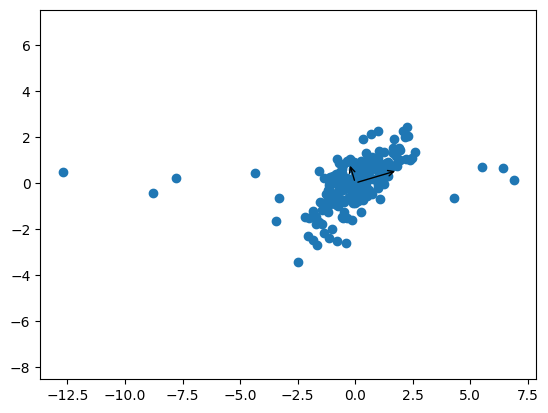

In [18]:
plot(X)

Covariance is not normalized (can't distinguish between scale and correlation strength), meaning outliers like these (under the assumption that more variance = more information) break PCA with disproportional influence away from the trend in the data.

## Exercise 3: Dimensionality reduction with PCA (1/2)
1. Plot a scatter of the data, including coloring of datapoints according to their classes.
1. Compute and plot the PCs;
1. Project the data onto each of the PCs and plot the projection (e.g. as a histogram);
1. Which of the PCs is more adequate to perform dimensionality reduction in the labelled dataset?

In [6]:
def make_pca_3(N, seed=42):
    rng = np.random.default_rng(seed)
    c0 = rng.multivariate_normal([-0.88, -0.87], [[1.10, 0.57], [0.57, 1.00]], size=N // 2)
    c1 = rng.multivariate_normal([1.05, 0.94], [[0.88, 0.29], [0.29, 0.94]], size=N // 2)
    X = np.vstack([c0, c1])
    y = np.concatenate([np.zeros(len(c0), dtype=int), np.ones(len(c1), dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

X, y = make_pca_3(N=200)

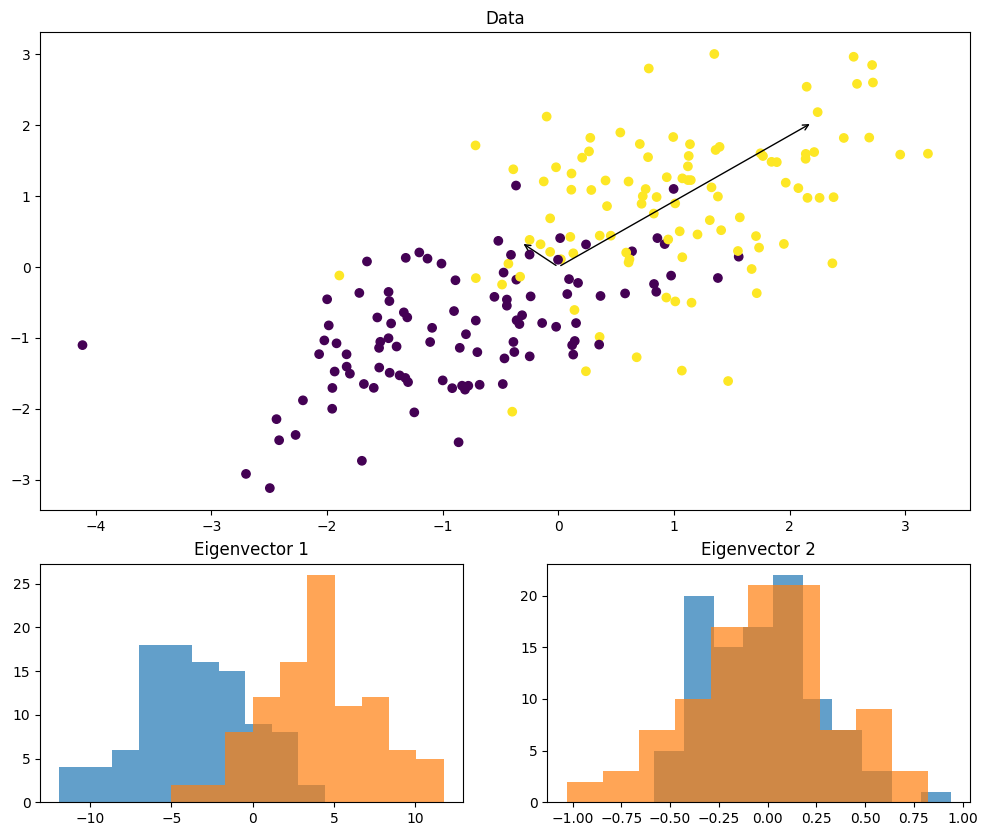

In [7]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.15, height_ratios = (2, 1))

ax_top = fig.add_subplot(gs[0, :])
ax_top.set_title("Data")

ax_botleft = fig.add_subplot(gs[1, 0])
ax_botleft.set_title("Eigenvector 1")

ax_botright = fig.add_subplot(gs[1, 1])
ax_botright.set_title("Eigenvector 2")


# TODO: Colormap for matching color
ax_top.scatter(*X.T, c=y)
mask = y == 0

cov_mat = np.cov(X.T)

eigenvals, eigenvecs = np.linalg.eig(cov_mat)

idx = eigenvals.argsort()[::-1]   
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:,idx]

for val, vec, ax in zip(eigenvals, eigenvecs.T, [ax_botleft, ax_botright]):
    ax_top.annotate("", xytext=(0, 0), xy=vec * val,
                arrowprops=dict(arrowstyle="->"))
    # Project
    eig = vec.reshape(-1, 1) * val

    projected = X @ eig
    ax.hist(projected[mask], alpha=0.7)
    ax.hist(projected[~mask], alpha=0.7)

Eigenvector 1 (with the highest eigenvalue) carries the most spread between classes over.

## Exercise 4: Dimensionality reduction with PCA (2/2)
1. Plot a scatter of the data, including coloring of datapoints according to their classes.
1. Compute and plot the PCs;
1. Project the data onto each of the PCs and plot the projection (e.g., as a histogram);
1. What is the most relevant PC, given that the goal is to perform dimensionality reduction for a classification task? Please also compare your answer to exercise 4.

In [8]:
def make_pca_4(N, seed=42):
    rng = np.random.default_rng(seed)
    c0 = rng.multivariate_normal([-0.36, 0.65], [[1.10, 0.98], [0.98, 1.05]], size=N // 2)
    c1 = rng.multivariate_normal([0.52, -0.53], [[0.81, 0.70], [0.70, 0.84]], size=N // 2)
    X = np.vstack([c0, c1])
    y = np.concatenate([np.zeros(len(c0), dtype=int), np.ones(len(c1), dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

X, y = make_pca_4(N=200)

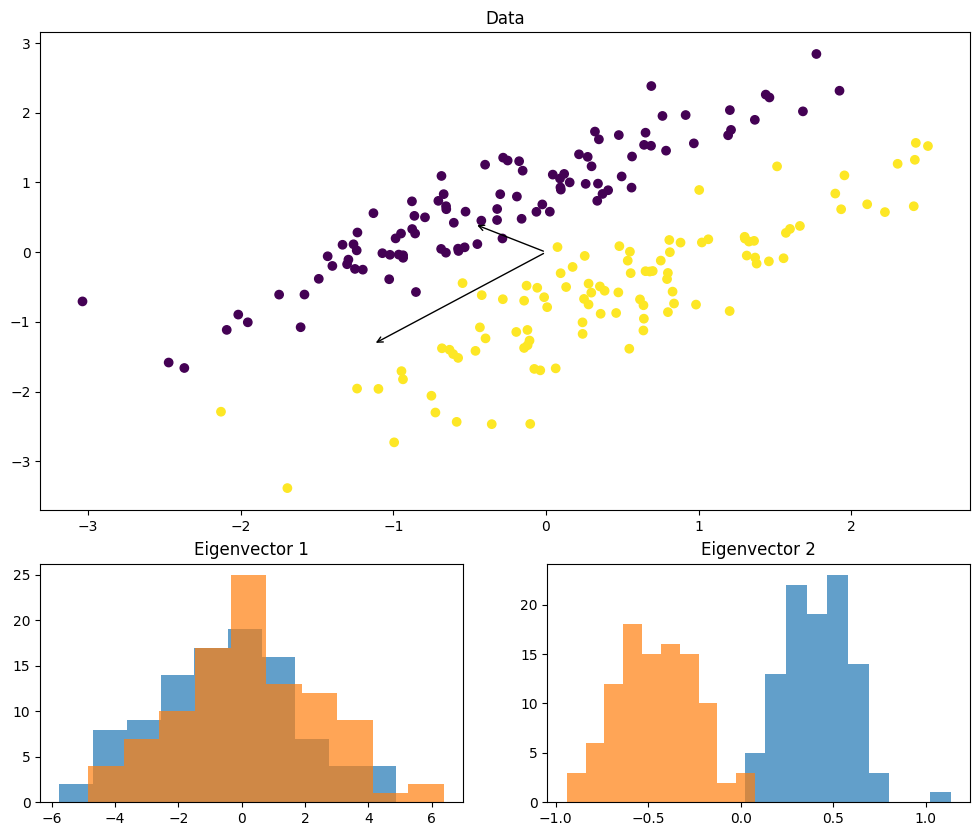

In [9]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.15, height_ratios = (2, 1))

ax_top = fig.add_subplot(gs[0, :])
ax_top.set_title("Data")

ax_botleft = fig.add_subplot(gs[1, 0])
ax_botleft.set_title("Eigenvector 1")

ax_botright = fig.add_subplot(gs[1, 1])
ax_botright.set_title("Eigenvector 2")


# TODO: Colormap for matching color
ax_top.scatter(*X.T, c=y)
mask = y == 0

cov_mat = np.cov(X.T)

eigenvals, eigenvecs = np.linalg.eig(cov_mat)

idx = eigenvals.argsort()[::-1]   
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:,idx]

for val, vec, ax in zip(eigenvals, eigenvecs.T, [ax_botleft, ax_botright]):
    ax_top.annotate("", xytext=(0, 0), xy=vec * val,
                arrowprops=dict(arrowstyle="->"))
    # Project
    eig = vec.reshape(-1, 1) * val

    projected = X @ eig
    ax.hist(projected[mask], alpha=0.7)
    ax.hist(projected[~mask], alpha=0.7)

Eigenvector 2 (with the smaller eigenvalue) seems like the best projection. Because, while it doesn't carry the most spread over, it carries the most spread between classes (the type we're interested in) over.

## Exercise 5: Selecting the number of PCs (1/2)
1. Compute the PCs;
1. Plot the eigenvalue spectrum;
1. By visually inspecting the eigenvalue spectrum of the covariance matrix, how many components do you think are necessary to achieve a good representation of the variance of the data? **Hint:** The magnitude of the eigenvalues represents the contribution of the corresponding PC to the variance of the data.


In [20]:
def make_pca_5(N, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((N, 100))
    M = rng.standard_normal((100, 100)) * 1.0
    X = Z @ M
    signal_var = [1180.0, 1100.0, 820.0]
    A = rng.standard_normal((100, len(signal_var)))
    Q = np.linalg.qr(A)[0][:, :len(signal_var)]
    F = rng.standard_normal((N, len(signal_var))) * np.sqrt(signal_var)
    X = X + F @ Q.T
    return X - X.mean(0)

X = make_pca_5(N=1000)
X.shape

(1000, 100)

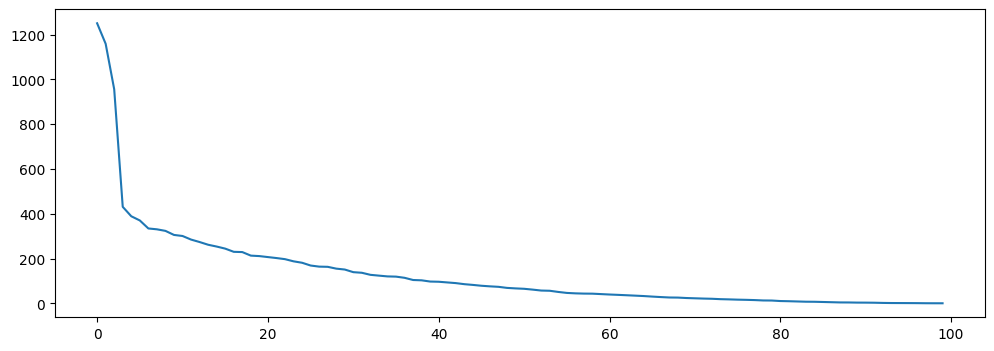

In [26]:
cov_mat = np.cov(X.T)

eigvals, _ = np.linalg.eig(cov_mat)
eigvals[::-1].sort()

plt.figure(figsize=(12, 4))
# plt.xlim(0, 5)  # Zooming in for more detail at turning point
plt.plot(eigvals)

Applying the same elbow method as for kNN, value 3 seems like the turning point.

## Exercise 6: Selecting the number of PCs (2/2)
Visually inspecting the eigenvalue spectrum of the covariance matrix does not always provide a clear criterion for the selection of the number of relevant components (i.e., it is subjective). If that is the case, an alternative criterion might be used: Typically, the number of PC is selected so as to achieve approximately 90% of the accumulated variance. 
**Note:** This is only a rule of thumb; values of 95% or 99% are also often seen.

1. Using the cumulative variance criterion, how many components should be selected for performing dimensionality reduction in the following dataset? **Hint:** The eigenvalues represent the variance explained by the corresponding PC.

In [29]:
def make_pca_6(N, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((N, 100))
    M = rng.standard_normal((100, 100)) * 1.0
    X = Z @ M
    return X - X.mean(0)

X = make_pca_6(N=1000)

Minimum PCs needed for 90% preserved variance: 50
Actual preserved variance at 50 dimensions: 90.56%


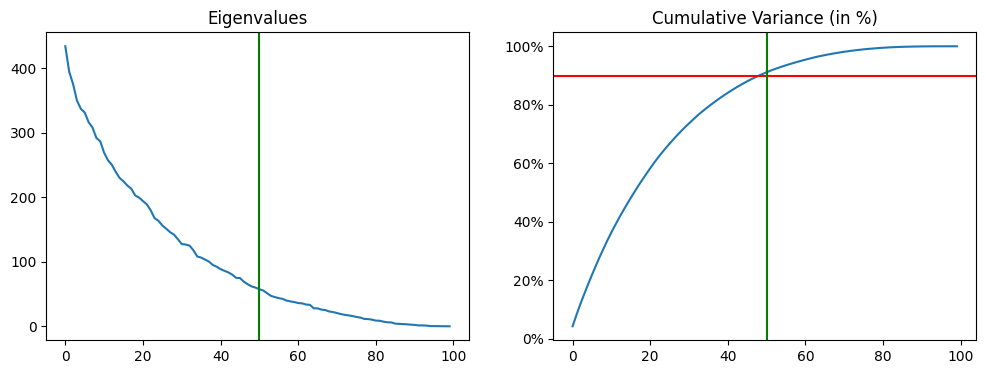

In [41]:
import matplotlib.ticker as mtick

cov_mat = np.cov(X.T)

eigvals, _ = np.linalg.eig(cov_mat)
eigvals[::-1].sort()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(eigvals)
ax[0].set_title("Eigenvalues")

eigvals_norm_cum = np.cumsum(eigvals / np.sum(eigvals) * 100)
ax[1].plot(eigvals_norm_cum)
ax[1].set_title("Cumulative Variance (in %)")
ax[1].axhline(90, color="red")
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter())

min_pcs = np.argmax(eigvals_norm_cum >= 90) + 1
print("Minimum PCs needed for 90% preserved variance:", min_pcs)
print(f"Actual preserved variance at {min_pcs} dimensions: {round(eigvals_norm_cum[min_pcs-1], 2)}%")

ax[0].axvline(min_pcs, color="green")
ax[1].axvline(min_pcs, color="green")